# Eco Predict — Complete ML Pipeline
### Gomti Nagar, Lucknow, Uttar Pradesh | CPCB/UPPCB hourly data

**7-Day Prototype — ML Stage**

This notebook contains:
- Data loading and validation
- Cleaning and EDA
- PM2.5 24-hour forecasting
- Model comparison
- Anomaly detection
- Environmental risk scoring
- Inspection/event prioritization
- Model and output saving

> **Important:** Risk and inspection scores are prototype decision-support indicators. They are not official regulatory classifications or automatic enforcement decisions.


In [1]:
# 1. Imports and project paths

import os
import glob
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FORECAST_HORIZON = 24
TARGET = "PM2.5 (µg/m³)"

# Notebook is inside EcoPredict/ml/
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "models")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

for folder in [PROCESSED_DIR, MODEL_DIR, OUTPUT_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project:", BASE_DIR)
print("Raw data:", RAW_DIR)
print("CSV files:")
for f in sorted(glob.glob(os.path.join(RAW_DIR, "*.csv"))):
    print(" -", os.path.basename(f))


Project: C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict
Raw data: C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\raw
CSV files:
 - air_2024.csv
 - air_2025.csv
 - air_2026.csv


In [2]:
# 2. Load and combine 2024, 2025 and 2026 CSV files

files = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))

# Ignore the old 2009 file if it was accidentally placed in the folder
files = [f for f in files if "2009" not in os.path.basename(f).lower()]

if not files:
    raise FileNotFoundError("No suitable CSV files found in EcoPredict/data/raw/.")

frames = []
for file in files:
    temp = pd.read_csv(file)
    temp["source_file"] = os.path.basename(file)
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

print("Combined shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


Combined shape: (22632, 26)
Columns:
['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)', 'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'source_file']


In [3]:
# 3. Clean timestamps, numeric columns and duplicates

df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

for col in df.columns:
    if col not in ["Timestamp", "source_file"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Timestamp"])
df = df.sort_values("Timestamp")
df = df.drop_duplicates(subset=["Timestamp"], keep="last").reset_index(drop=True)

print("Date range:", df["Timestamp"].min(), "to", df["Timestamp"].max())
print("Rows:", len(df))

# Check hourly gaps
hour_gap = df["Timestamp"].diff().dt.total_seconds().div(3600)
print("Gaps > 1 hour:", int((hour_gap > 1).sum()))


Date range: 2024-01-01 00:00:00 to 2026-08-31 23:00:00
Rows: 22632
Gaps > 1 hour: 1


In [4]:
# 4. Missing-value analysis

missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_percent")
)

display(missing)

if TARGET not in df.columns:
    raise ValueError(f"{TARGET} not found in dataset.")

print("PM2.5 missing:", int(df[TARGET].isna().sum()))


,missing_percent
NH3 (µg/m³),100.000000
O Xylene (µg/m³),100.000000
Eth-Benzene (µg/m³),100.000000
MP-Xylene (µg/m³),100.000000
Xylene (µg/m³),80.620361
BP (mmHg),66.207140
SO2 (µg/m³),8.333333
Toluene (µg/m³),7.935666
Benzene (µg/m³),7.931248
CO (mg/m³),6.322906


PM2.5 missing: 568


## 5. Exploratory Data Analysis

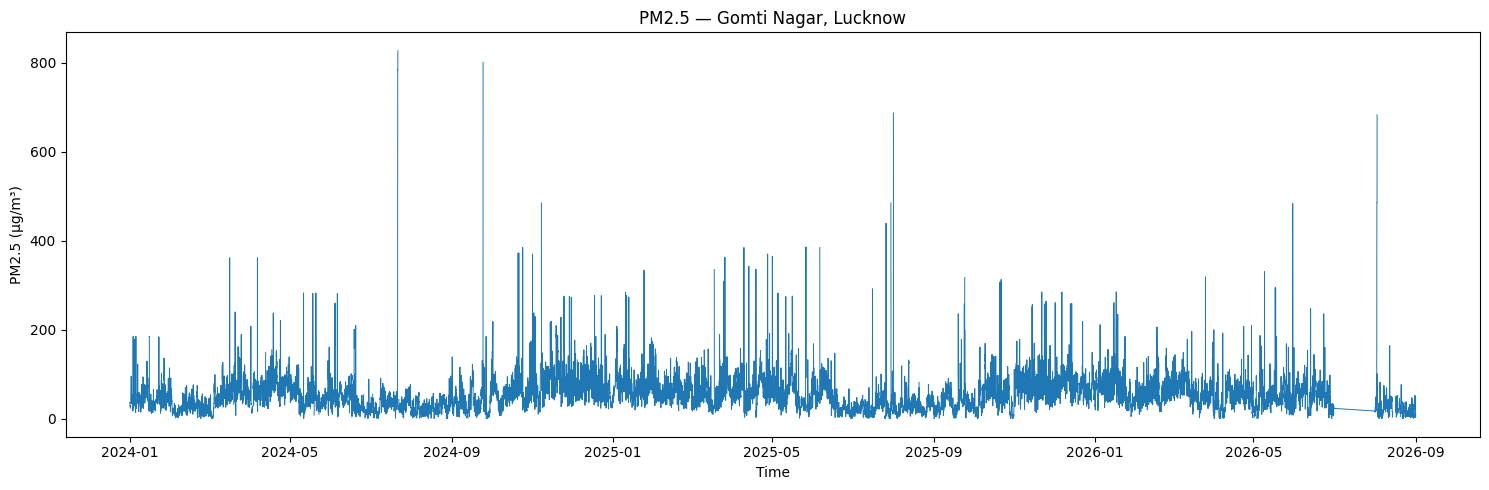

In [5]:
# PM2.5 over time

plt.figure(figsize=(15, 5))
plt.plot(df["Timestamp"], df[TARGET], linewidth=0.7)
plt.title("PM2.5 — Gomti Nagar, Lucknow")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


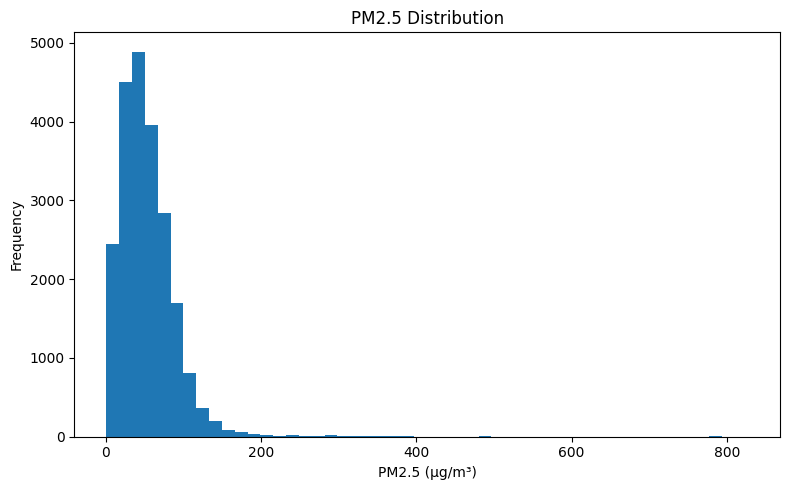

count    22064.000000
mean        53.991957
std         39.690118
min          1.000000
25%         29.250000
50%         47.750000
75%         70.750000
max        827.000000
Name: PM2.5 (µg/m³), dtype: float64

In [6]:
# PM2.5 distribution

plt.figure(figsize=(8, 5))
plt.hist(df[TARGET].dropna(), bins=50)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(df[TARGET].describe())


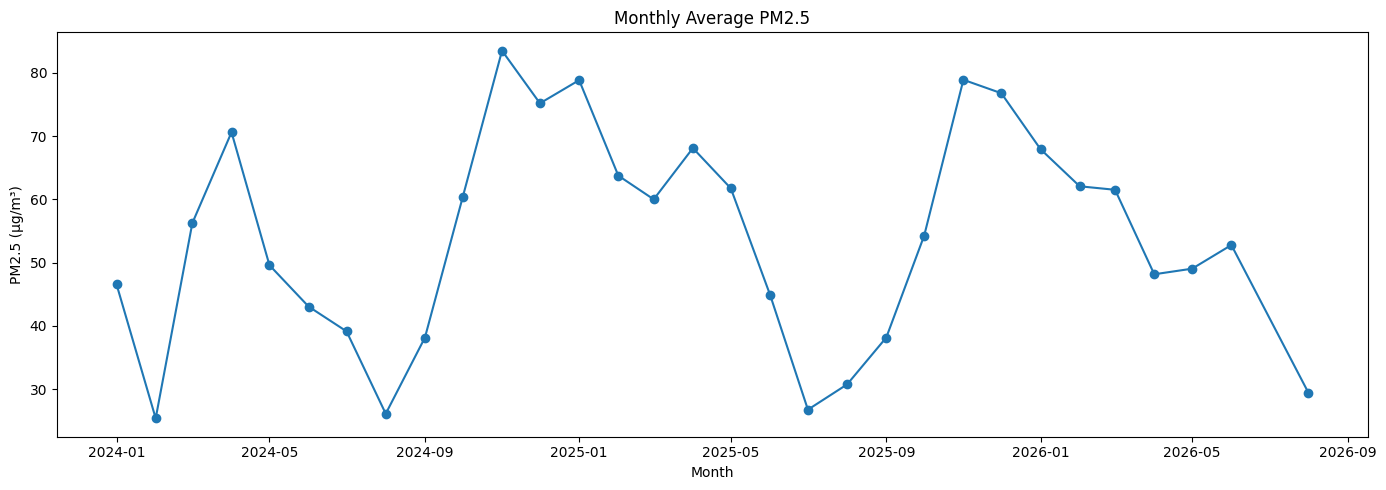

In [7]:
# Monthly PM2.5 average

monthly = (
    df.set_index("Timestamp")[TARGET]
      .resample("MS")
      .mean()
      .dropna()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()


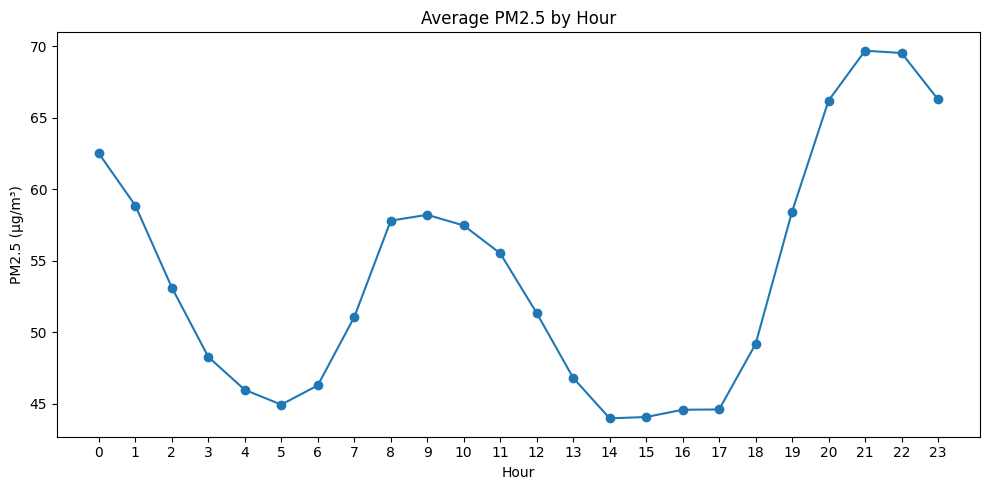

In [8]:
# Hour-of-day pattern

hourly_avg = df.groupby(df["Timestamp"].dt.hour)[TARGET].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


In [9]:
# Correlation with available environmental variables

candidate_cols = [
    TARGET, "PM10 (µg/m³)", "NO (µg/m³)", "NO2 (µg/m³)",
    "NOx (ppb)", "NH3 (µg/m³)", "SO2 (µg/m³)", "CO (mg/m³)",
    "Ozone (µg/m³)", "AT (°C)", "RH (%)", "WS (m/s)",
    "WD (deg)", "RF (mm)", "SR (W/mt2)", "BP (mmHg)", "VWS (m/s)"
]

corr_cols = [c for c in candidate_cols if c in df.columns]
display(df[corr_cols].corr(numeric_only=True)[TARGET].sort_values(ascending=False).to_frame("correlation"))


,correlation
PM2.5 (µg/m³),1.000000
PM10 (µg/m³),0.948915
WD (deg),0.069081
SO2 (µg/m³),0.035693
VWS (m/s),-0.001616
RF (mm),-0.025354
SR (W/mt2),-0.033928
CO (mg/m³),-0.060332
BP (mmHg),-0.082483
NOx (ppb),-0.083606


## 6. PM2.5 24-Hour Forecasting

We use historical PM2.5 behaviour plus calendar features.

The target is:

**PM2.5 at time t + 24 hours**


In [10]:
# 6.1 Feature engineering

data = df.copy()

# Calendar features
data["hour"] = data["Timestamp"].dt.hour
data["day_of_week"] = data["Timestamp"].dt.dayofweek
data["month"] = data["Timestamp"].dt.month
data["day_of_year"] = data["Timestamp"].dt.dayofyear
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

# Cyclic time features
data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

# PM2.5 lag features
for lag in [1, 3, 6, 12, 24, 48, 72, 168]:
    data[f"pm25_lag_{lag}"] = data[TARGET].shift(lag)

# Rolling statistics use only previous observations
for window in [6, 12, 24, 72]:
    data[f"pm25_roll_mean_{window}"] = data[TARGET].shift(1).rolling(window).mean()
    data[f"pm25_roll_std_{window}"] = data[TARGET].shift(1).rolling(window).std()

# 24-hour future target
data["target_pm25_24h"] = data[TARGET].shift(-FORECAST_HORIZON)

FEATURES = [
    "hour", "day_of_week", "month", "day_of_year", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "pm25_lag_1", "pm25_lag_3", "pm25_lag_6", "pm25_lag_12",
    "pm25_lag_24", "pm25_lag_48", "pm25_lag_72", "pm25_lag_168",
    "pm25_roll_mean_6", "pm25_roll_std_6",
    "pm25_roll_mean_12", "pm25_roll_std_12",
    "pm25_roll_mean_24", "pm25_roll_std_24",
    "pm25_roll_mean_72", "pm25_roll_std_72"
]

model_data = (
    data[["Timestamp", TARGET, "target_pm25_24h"] + FEATURES]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)

print("Final ML rows:", len(model_data))
print("Features:", len(FEATURES))


Final ML rows: 14920
Features: 25


In [11]:
# 6.2 Time-based train/test split

train = model_data[model_data["Timestamp"].dt.year < 2026].copy()
test = model_data[model_data["Timestamp"].dt.year == 2026].copy()

# Safety fallback if 2026 is unavailable
if len(test) == 0:
    split = int(len(model_data) * 0.8)
    train = model_data.iloc[:split].copy()
    test = model_data.iloc[split:].copy()

X_train = train[FEATURES]
y_train = train["target_pm25_24h"]

X_test = test[FEATURES]
y_test = test["target_pm25_24h"]

print("Train rows:", len(train))
print("Test rows :", len(test))
print("Train period:", train["Timestamp"].min(), "to", train["Timestamp"].max())
print("Test period :", test["Timestamp"].min(), "to", test["Timestamp"].max())


Train rows: 11057
Test rows : 3863
Train period: 2024-01-11 17:00:00 to 2025-12-31 23:00:00
Test period : 2026-01-01 00:00:00 to 2026-08-30 23:00:00


In [12]:
# 7. Random Forest

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE : {rf_mae:.3f}")
print(f"Random Forest RMSE: {rf_rmse:.3f}")
print(f"Random Forest R²  : {rf_r2:.3f}")


Random Forest MAE : 20.898
Random Forest RMSE: 32.175
Random Forest R²  : 0.037


In [13]:
# 8. HistGradientBoosting

hgb = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

hgb.fit(X_train, y_train)
hgb_pred = hgb.predict(X_test)

hgb_mae = mean_absolute_error(y_test, hgb_pred)
hgb_rmse = np.sqrt(mean_squared_error(y_test, hgb_pred))
hgb_r2 = r2_score(y_test, hgb_pred)

print(f"HistGradientBoosting MAE : {hgb_mae:.3f}")
print(f"HistGradientBoosting RMSE: {hgb_rmse:.3f}")
print(f"HistGradientBoosting R²  : {hgb_r2:.3f}")


HistGradientBoosting MAE : 21.549
HistGradientBoosting RMSE: 31.290
HistGradientBoosting R²  : 0.089


In [14]:
# 9. Select best forecasting model

results = pd.DataFrame({
    "Model": ["Random Forest", "HistGradientBoosting"],
    "MAE": [rf_mae, hgb_mae],
    "RMSE": [rf_rmse, hgb_rmse],
    "R2": [rf_r2, hgb_r2]
}).sort_values("MAE").reset_index(drop=True)

display(results)

if hgb_mae <= rf_mae:
    best_model = hgb
    best_pred = hgb_pred
    best_model_name = "HistGradientBoosting"
else:
    best_model = rf
    best_pred = rf_pred
    best_model_name = "Random Forest"

print("Selected model:", best_model_name)


,Model,MAE,RMSE,R2
0,Random Forest,20.897639,32.174975,0.036853
1,HistGradientBoosting,21.548650,31.289910,0.089113


Selected model: Random Forest


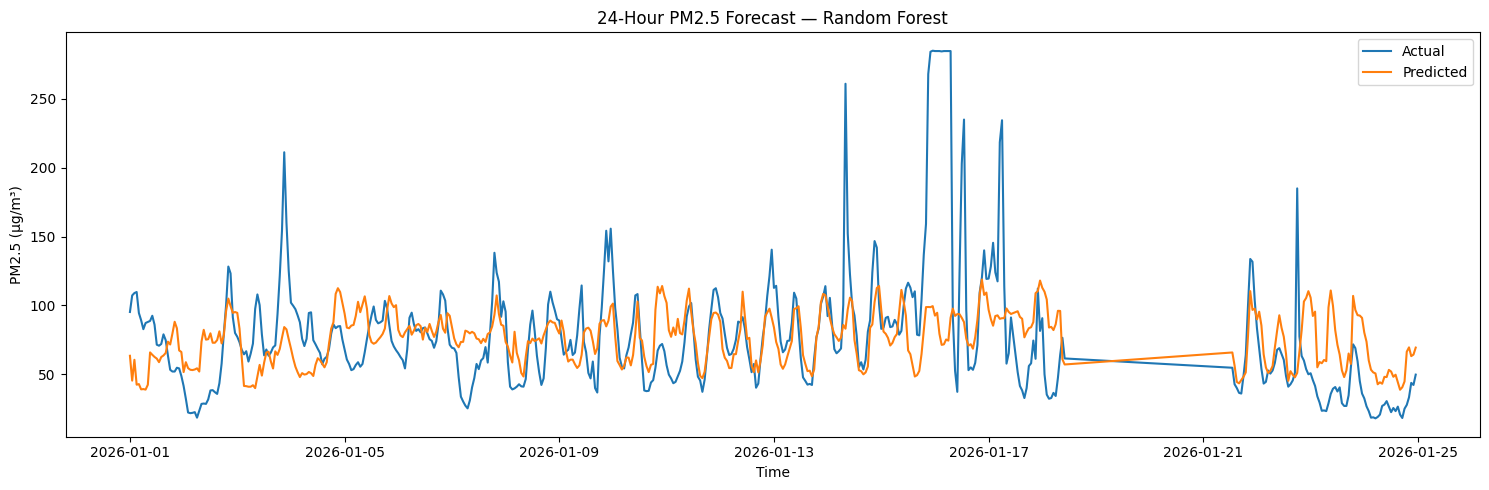

In [15]:
# 10. Actual vs predicted

n = min(500, len(test))

plt.figure(figsize=(15, 5))
plt.plot(test["Timestamp"].iloc[:n], y_test.iloc[:n].values, label="Actual")
plt.plot(test["Timestamp"].iloc[:n], best_pred[:n], label="Predicted")
plt.title(f"24-Hour PM2.5 Forecast — {best_model_name}")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


MAE : 20.89763929702203
RMSE: 32.1749754167205
R²  : 0.03685328962007928


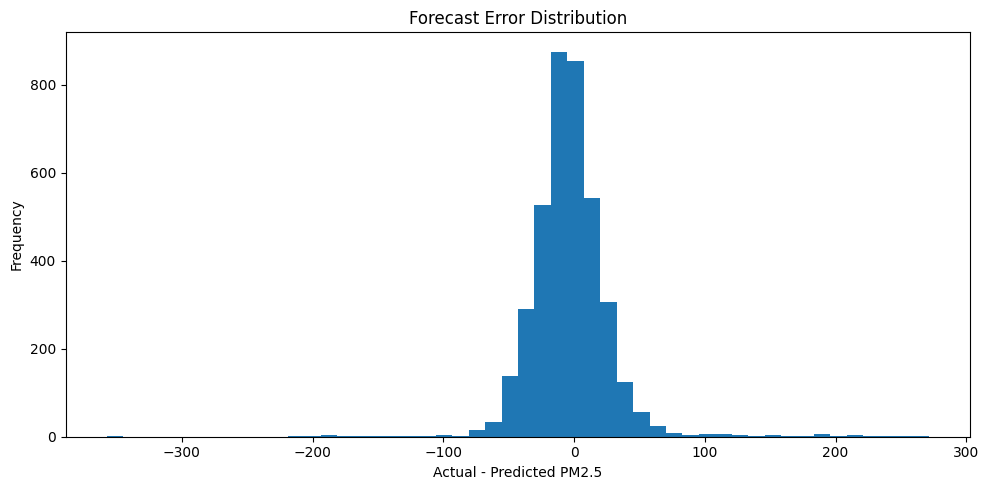

In [16]:
# 11. Forecast error analysis

errors = y_test.values - best_pred

print("MAE :", mean_absolute_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R²  :", r2_score(y_test, best_pred))

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50)
plt.title("Forecast Error Distribution")
plt.xlabel("Actual - Predicted PM2.5")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


,importance
pm25_lag_1,0.228593
pm25_roll_mean_24,0.107353
pm25_lag_24,0.084441
pm25_roll_std_72,0.071218
pm25_roll_mean_72,0.047846
day_of_year,0.042892
pm25_lag_12,0.041036
pm25_roll_std_12,0.039642
pm25_roll_std_24,0.039369
pm25_lag_168,0.034091


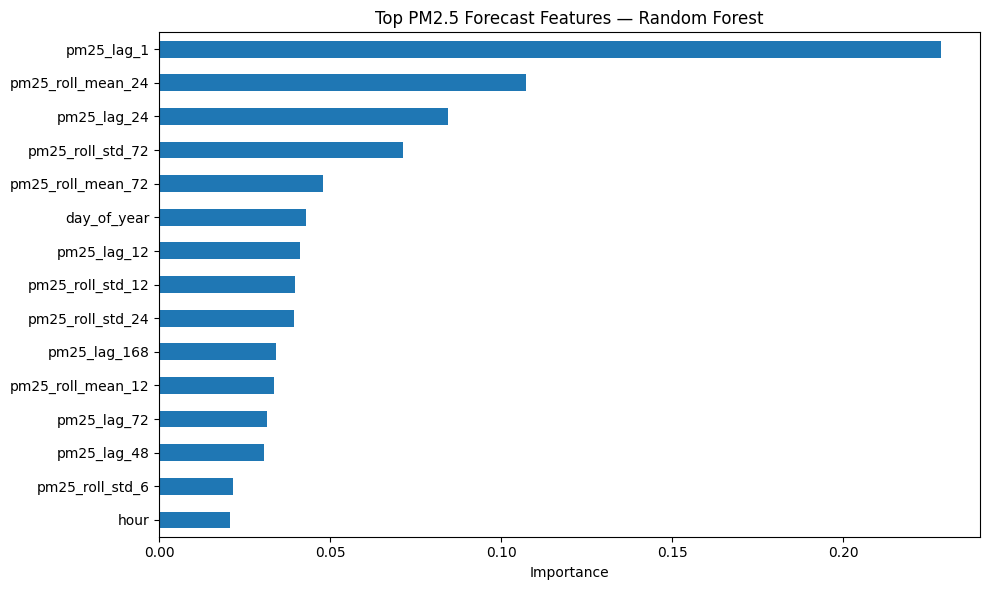

In [17]:
# 12. Feature importance for Random Forest
# HistGradientBoosting does not expose feature_importances_.

importance = pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=False).head(15)

display(importance.to_frame("importance"))

plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind="barh")
plt.title("Top PM2.5 Forecast Features — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# DAY 2 — Environmental Intelligence

## 13. Anomaly Detection

We use **Isolation Forest** to flag unusual PM2.5 observations.

An anomaly means:

> The observation is unusual compared with the normal pattern in the training data.

It is a **screening signal**, not proof of a violation.


In [18]:
# 13. Prepare anomaly features

anomaly_data = df[["Timestamp", TARGET]].copy()

# Add useful pollution/context variables when available
for col in ["PM10 (µg/m³)", "NO2 (µg/m³)", "SO2 (µg/m³)", "CO (mg/m³)", "Ozone (µg/m³)", "AT (°C)", "RH (%)", "WS (m/s)"]:
    if col in df.columns:
        anomaly_data[col] = df[col]

# Time features
anomaly_data["hour"] = anomaly_data["Timestamp"].dt.hour
anomaly_data["day_of_week"] = anomaly_data["Timestamp"].dt.dayofweek

# Fill missing numeric values with median
anomaly_features = [c for c in anomaly_data.columns if c not in ["Timestamp"]]
anomaly_X = anomaly_data[anomaly_features].copy()
anomaly_X = anomaly_X.fillna(anomaly_X.median(numeric_only=True))
anomaly_X = anomaly_X.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Anomaly features:", anomaly_features)


Anomaly features: ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'hour', 'day_of_week']


In [19]:
# 14. Train Isolation Forest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=RANDOM_STATE
)

anomaly_data["anomaly_label"] = iso.fit_predict(anomaly_X)
anomaly_data["anomaly_score"] = -iso.score_samples(anomaly_X)

# -1 = anomaly, +1 = normal
anomaly_data["is_anomaly"] = (anomaly_data["anomaly_label"] == -1).astype(int)

print("Anomalies detected:", int(anomaly_data["is_anomaly"].sum()))
print("Anomaly percentage:", round(anomaly_data["is_anomaly"].mean() * 100, 2), "%")


Anomalies detected: 679
Anomaly percentage: 3.0 %


In [20]:
# 15. Show detected anomalies

anomalies = (
    anomaly_data[anomaly_data["is_anomaly"] == 1]
    [["Timestamp", TARGET, "anomaly_score"]]
    .sort_values("anomaly_score", ascending=False)
)

display(anomalies.head(20))


,Timestamp,PM2.5 (µg/m³),anomaly_score
1966,2024-03-22 22:00:00,162.25,0.701869
1967,2024-03-22 23:00:00,132.25,0.692564
1989,2024-03-23 21:00:00,121.00,0.681689
2026,2024-03-25 10:00:00,156.00,0.677332
1990,2024-03-23 22:00:00,137.25,0.676260
1988,2024-03-23 20:00:00,107.00,0.673365
1968,2024-03-23 00:00:00,117.00,0.673117
1976,2024-03-23 08:00:00,152.25,0.672151
2017,2024-03-25 01:00:00,135.50,0.670148
2027,2024-03-25 11:00:00,140.00,0.669764


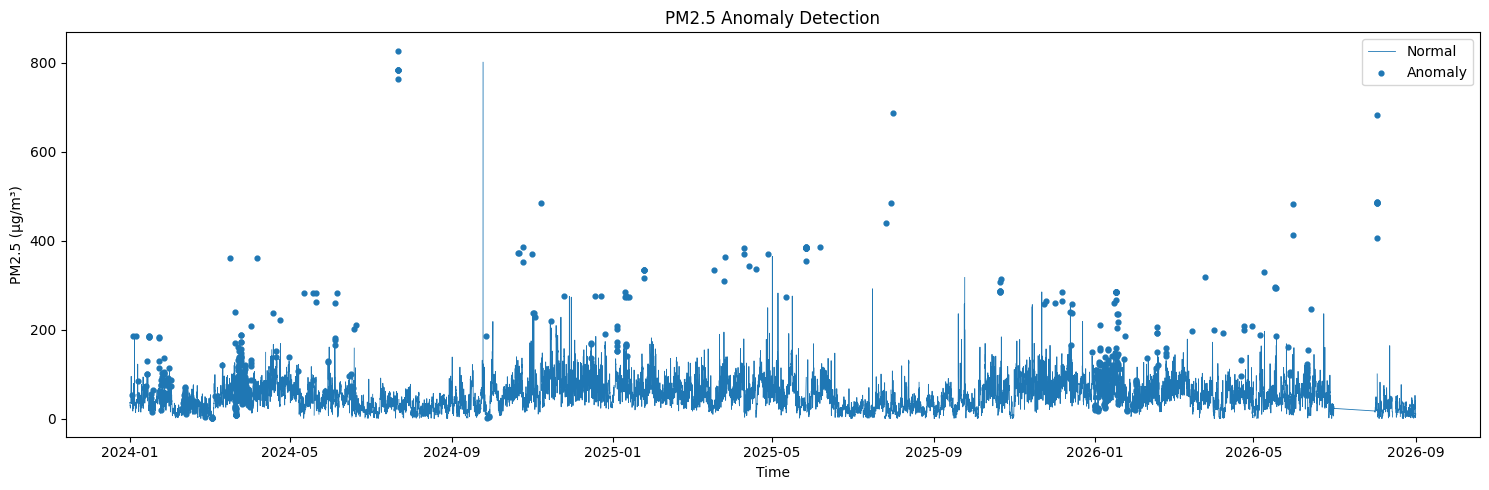

In [21]:
# 16. Visualize anomalies

plt.figure(figsize=(15, 5))

normal = anomaly_data["is_anomaly"] == 0
abnormal = anomaly_data["is_anomaly"] == 1

plt.plot(
    anomaly_data.loc[normal, "Timestamp"],
    anomaly_data.loc[normal, TARGET],
    linewidth=0.6,
    label="Normal"
)

plt.scatter(
    anomaly_data.loc[abnormal, "Timestamp"],
    anomaly_data.loc[abnormal, TARGET],
    s=12,
    label="Anomaly"
)

plt.title("PM2.5 Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()


## 17. Risk Scoring

We combine:
- Current PM2.5
- 24-hour predicted PM2.5
- Anomaly signal

to create a **0–100 prototype risk score**.


In [22]:
# 17. Build risk dataset

risk_df = test[["Timestamp", TARGET, "target_pm25_24h"]].copy()
risk_df = risk_df.rename(columns={"target_pm25_24h": "actual_pm25_24h"})

# Add model forecast
risk_df["predicted_pm25_24h"] = best_pred

# Match anomaly information by timestamp
risk_lookup = anomaly_data[["Timestamp", "is_anomaly", "anomaly_score"]]
risk_df = risk_df.merge(risk_lookup, on="Timestamp", how="left")

risk_df["is_anomaly"] = risk_df["is_anomaly"].fillna(0).astype(int)
risk_df["anomaly_score"] = risk_df["anomaly_score"].fillna(0)

# Clip values for stable scoring
current_component = np.clip(risk_df[TARGET] / 200 * 40, 0, 40)
forecast_component = np.clip(risk_df["predicted_pm25_24h"] / 200 * 40, 0, 40)
anomaly_component = risk_df["is_anomaly"] * 20

risk_df["risk_score"] = np.clip(
    current_component + forecast_component + anomaly_component,
    0,
    100
)

def risk_category(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Moderate"
    elif score < 75:
        return "High"
    return "Critical"

risk_df["risk_category"] = risk_df["risk_score"].apply(risk_category)

display(
    risk_df[
        ["Timestamp", TARGET, "predicted_pm25_24h", "is_anomaly", "risk_score", "risk_category"]
    ].head(20)
)


,Timestamp,PM2.5 (µg/m³),predicted_pm25_24h,is_anomaly,risk_score,risk_category
0,2026-01-01 00:00:00,28.50,63.431051,1,38.386210,Moderate
1,2026-01-01 01:00:00,30.50,45.396560,1,35.179312,Moderate
2,2026-01-01 02:00:00,27.75,60.520259,1,37.654052,Moderate
3,2026-01-01 03:00:00,26.00,42.448260,1,33.689652,Moderate
4,2026-01-01 04:00:00,21.75,42.875579,1,32.925116,Moderate
5,2026-01-01 05:00:00,20.00,39.059549,1,31.811910,Moderate
6,2026-01-01 06:00:00,20.00,39.253188,0,11.850638,Low
7,2026-01-01 07:00:00,28.50,38.874417,1,33.474883,Moderate
8,2026-01-01 08:00:00,51.75,42.400656,0,18.830131,Low
9,2026-01-01 09:00:00,66.00,65.886177,0,26.377235,Moderate


risk_category
Low         2313
Moderate    1384
High         144
Critical      22
Name: count, dtype: int64


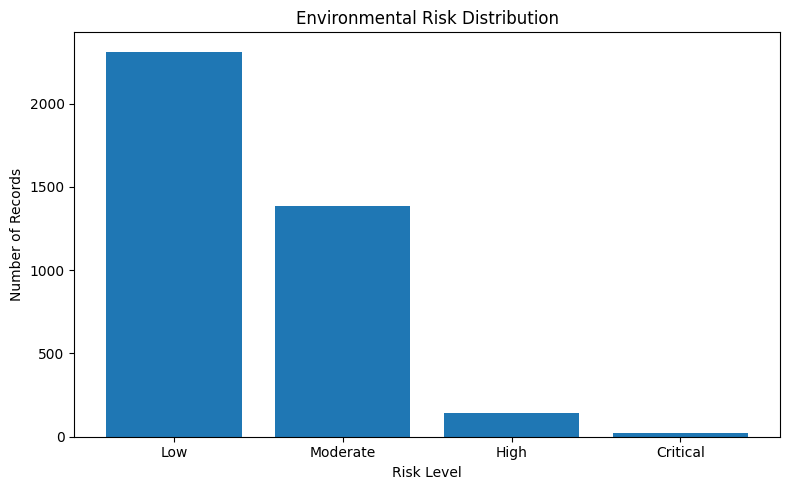

In [23]:
# 18. Risk distribution

print(risk_df["risk_category"].value_counts())

risk_order = ["Low", "Moderate", "High", "Critical"]
risk_counts = risk_df["risk_category"].value_counts().reindex(risk_order, fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Environmental Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


## 19. Inspection Prioritization

For the current prototype we have **one monitoring station**, so inspection priority is generated for **high-risk time/events**.

When the full system contains multiple stations/industries, the same logic will rank locations.


In [24]:
# Create inspection priority

inspection = risk_df.copy()

# Priority score emphasizes high risk and anomalies
inspection["inspection_priority_score"] = (
    inspection["risk_score"] * 0.8
    + inspection["is_anomaly"] * 20
)

inspection["priority_level"] = pd.cut(
    inspection["inspection_priority_score"],
    bins=[-np.inf, 30, 55, 75, np.inf],
    labels=["Low", "Medium", "High", "Urgent"]
)

inspection = inspection.sort_values(
    "inspection_priority_score",
    ascending=False
).reset_index(drop=True)

inspection["priority_rank"] = np.arange(1, len(inspection) + 1)

inspection_output = inspection[
    [
        "priority_rank",
        "Timestamp",
        TARGET,
        "predicted_pm25_24h",
        "is_anomaly",
        "risk_score",
        "risk_category",
        "inspection_priority_score",
        "priority_level"
    ]
]

display(inspection_output.head(20))


,priority_rank,Timestamp,PM2.5 (µg/m³),predicted_pm25_24h,is_anomaly,risk_score,risk_category,inspection_priority_score,priority_level
0,1,2026-01-16 21:00:00,268.00,118.792825,1,83.758565,Critical,87.006852,Urgent
1,2,2026-01-04 21:00:00,211.25,112.513173,1,82.502635,Critical,86.002108,Urgent
2,3,2026-02-16 23:00:00,206.25,110.039350,1,82.007870,Critical,85.606296,Urgent
3,4,2026-01-16 23:00:00,285.00,109.351177,1,81.870235,Critical,85.496188,Urgent
4,5,2026-01-16 22:00:00,284.25,107.648745,1,81.529749,Critical,85.223799,Urgent
5,6,2026-01-17 00:00:00,284.75,96.845679,1,79.369136,Critical,83.495309,Urgent
6,7,2026-01-17 13:00:00,235.00,95.776551,1,79.155310,Critical,83.324248,Urgent
7,8,2026-04-01 01:00:00,200.00,95.607897,1,79.121579,Critical,83.297264,Urgent
8,9,2026-01-15 08:00:00,261.00,95.527155,1,79.105431,Critical,83.284345,Urgent
9,10,2026-01-17 04:00:00,284.75,92.802248,1,78.560450,Critical,82.848360,Urgent


In [25]:
# 20. Top 10 inspection events for the dashboard

top_inspections = inspection_output.head(10).copy()

print("TOP INSPECTION PRIORITIES")
display(top_inspections)


TOP INSPECTION PRIORITIES


,priority_rank,Timestamp,PM2.5 (µg/m³),predicted_pm25_24h,is_anomaly,risk_score,risk_category,inspection_priority_score,priority_level
0,1,2026-01-16 21:00:00,268.00,118.792825,1,83.758565,Critical,87.006852,Urgent
1,2,2026-01-04 21:00:00,211.25,112.513173,1,82.502635,Critical,86.002108,Urgent
2,3,2026-02-16 23:00:00,206.25,110.039350,1,82.007870,Critical,85.606296,Urgent
3,4,2026-01-16 23:00:00,285.00,109.351177,1,81.870235,Critical,85.496188,Urgent
4,5,2026-01-16 22:00:00,284.25,107.648745,1,81.529749,Critical,85.223799,Urgent
5,6,2026-01-17 00:00:00,284.75,96.845679,1,79.369136,Critical,83.495309,Urgent
6,7,2026-01-17 13:00:00,235.00,95.776551,1,79.155310,Critical,83.324248,Urgent
7,8,2026-04-01 01:00:00,200.00,95.607897,1,79.121579,Critical,83.297264,Urgent
8,9,2026-01-15 08:00:00,261.00,95.527155,1,79.105431,Critical,83.284345,Urgent
9,10,2026-01-17 04:00:00,284.75,92.802248,1,78.560450,Critical,82.848360,Urgent


# 21. Latest Environmental Intelligence

Create the values that the future FastAPI backend can return to the React dashboard.


In [26]:
# Latest available forecast/risk information

latest_features = model_data.iloc[[-1]]
latest_timestamp = latest_features["Timestamp"].iloc[0]

latest_prediction = float(best_model.predict(latest_features[FEATURES])[0])

latest_anomaly_row = anomaly_data.iloc[-1]
latest_anomaly = int(latest_anomaly_row["is_anomaly"])

# Simple latest risk calculation
latest_current_pm25 = float(df[TARGET].dropna().iloc[-1])

latest_risk_score = float(np.clip(
    (latest_current_pm25 / 200 * 40)
    + (latest_prediction / 200 * 40)
    + (latest_anomaly * 20),
    0,
    100
))

latest_risk = risk_category(latest_risk_score)

latest_intelligence = {
    "location": "Gomti Nagar, Lucknow, Uttar Pradesh",
    "timestamp": str(latest_timestamp),
    "current_pm25": round(latest_current_pm25, 2),
    "predicted_pm25_24h": round(latest_prediction, 2),
    "anomaly_detected": bool(latest_anomaly),
    "risk_score": round(latest_risk_score, 2),
    "risk_category": latest_risk,
    "forecast_model": best_model_name
}

latest_intelligence


{'location': 'Gomti Nagar, Lucknow, Uttar Pradesh',
 'timestamp': '2026-08-30 23:00:00',
 'current_pm25': 11.33,
 'predicted_pm25_24h': 31.56,
 'anomaly_detected': False,
 'risk_score': 8.58,
 'risk_category': 'Low',
 'forecast_model': 'Random Forest'}

# 22. Save ML artifacts and outputs

These files will later be used by the **FastAPI backend**.


In [27]:
# Save forecasting model

forecast_package = {
    "model": best_model,
    "features": FEATURES,
    "target": TARGET,
    "forecast_horizon_hours": FORECAST_HORIZON,
    "location": "Gomti Nagar, Lucknow, Uttar Pradesh",
    "model_name": best_model_name
}

forecast_path = os.path.join(MODEL_DIR, "pm25_forecaster_24h.joblib")
joblib.dump(forecast_package, forecast_path)

# Save anomaly model
anomaly_path = os.path.join(MODEL_DIR, "pm25_anomaly_detector.joblib")
joblib.dump(
    {
        "model": iso,
        "features": anomaly_features,
        "location": "Gomti Nagar, Lucknow, Uttar Pradesh"
    },
    anomaly_path
)

# Save datasets and results
model_data.to_csv(
    os.path.join(PROCESSED_DIR, "pm25_ml_dataset.csv"),
    index=False
)

results.to_csv(
    os.path.join(MODEL_DIR, "pm25_model_metrics.csv"),
    index=False
)

risk_df.to_csv(
    os.path.join(OUTPUT_DIR, "risk_results.csv"),
    index=False
)

inspection_output.to_csv(
    os.path.join(OUTPUT_DIR, "inspection_priority.csv"),
    index=False
)

with open(os.path.join(OUTPUT_DIR, "latest_intelligence.json"), "w", encoding="utf-8") as f:
    import json
    json.dump(latest_intelligence, f, indent=4)

print("Saved:")
print("1.", forecast_path)
print("2.", anomaly_path)
print("3.", os.path.join(PROCESSED_DIR, "pm25_ml_dataset.csv"))
print("4.", os.path.join(MODEL_DIR, "pm25_model_metrics.csv"))
print("5.", os.path.join(OUTPUT_DIR, "risk_results.csv"))
print("6.", os.path.join(OUTPUT_DIR, "inspection_priority.csv"))
print("7.", os.path.join(OUTPUT_DIR, "latest_intelligence.json"))


Saved:
1. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_forecaster_24h.joblib
2. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_anomaly_detector.joblib
3. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\data\processed\pm25_ml_dataset.csv
4. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\models\pm25_model_metrics.csv
5. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\risk_results.csv
6. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\inspection_priority.csv
7. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\latest_intelligence.json


# ✅ Day 1 + Day 2 Complete

### Forecasting
- PM2.5 24-hour forecasting
- Random Forest
- HistGradientBoosting
- Best model selection
- Evaluation and plots

### Environmental Intelligence
- Isolation Forest anomaly detection
- 0–100 risk score
- Low / Moderate / High / Critical risk
- Inspection/event prioritization
- Dashboard-ready latest intelligence

### Next in the 7-day plan
**Day 3 → Policy Simulator + Action Recommendation**


# 🚀 Day 3 — Policy Intelligence Engine

## Goal
Turn the forecasting/risk outputs from Day 1–2 into a **decision-support layer**:

**Forecast → Policy Scenario → Impact Estimate → Budget Recommendation → Verification**

> **Important:** Policy impacts in this prototype are **scenario estimates**, not causal claims. The current Gomti Nagar dataset does not contain direct intervention variables such as vehicle activity, industrial production, or policy implementation dates. Therefore, the simulator uses transparent, user-editable scenario assumptions.

## 23. Policy Scenario Library

We define a small policy library for the prototype.  
Each policy has:
- a lever
- an assumed PM2.5 reduction percentage
- a relative budget requirement
- an implementation priority

The assumed impact is deliberately kept separate from the ML forecast so the dashboard can clearly label it as a **scenario estimate**.

In [28]:
# 23. Policy Scenario Library

policy_library = pd.DataFrame([
    {
        "policy_id": "P01",
        "policy": "Reduce heavy vehicle activity",
        "lever": "Traffic / heavy vehicles",
        "assumed_pm25_reduction_pct": 5.0,
        "budget_units": 3,
        "description": "Scenario: reduce heavy-vehicle activity during high-risk periods."
    },
    {
        "policy_id": "P02",
        "policy": "Improve industrial emission efficiency",
        "lever": "Industrial emissions",
        "assumed_pm25_reduction_pct": 8.0,
        "budget_units": 4,
        "description": "Scenario: improve emission-control efficiency at priority facilities."
    },
    {
        "policy_id": "P03",
        "policy": "Shift trips to public transport",
        "lever": "Transport demand",
        "assumed_pm25_reduction_pct": 4.0,
        "budget_units": 2,
        "description": "Scenario: shift a portion of private trips to public transport."
    },
    {
        "policy_id": "P04",
        "policy": "Cleaner energy transition",
        "lever": "Fuel / energy",
        "assumed_pm25_reduction_pct": 6.0,
        "budget_units": 5,
        "description": "Scenario: increase cleaner energy/fuel usage."
    },
    {
        "policy_id": "P05",
        "policy": "Targeted green intervention",
        "lever": "Local mitigation",
        "assumed_pm25_reduction_pct": 2.5,
        "budget_units": 1,
        "description": "Scenario: targeted local mitigation in priority areas."
    }
])

display(policy_library)
print("\nThese percentages are prototype assumptions and must be replaced/calibrated with intervention data in a production system.")

,policy_id,policy,lever,assumed_pm25_reduction_pct,budget_units,description
0,P01,Reduce heavy vehicle activity,Traffic / heavy vehicles,5.0,3,Scenario: reduce heavy-vehicle activity during...
1,P02,Improve industrial emission efficiency,Industrial emissions,8.0,4,Scenario: improve emission-control efficiency ...
2,P03,Shift trips to public transport,Transport demand,4.0,2,Scenario: shift a portion of private trips to ...
3,P04,Cleaner energy transition,Fuel / energy,6.0,5,Scenario: increase cleaner energy/fuel usage.
4,P05,Targeted green intervention,Local mitigation,2.5,1,Scenario: targeted local mitigation in priorit...



These percentages are prototype assumptions and must be replaced/calibrated with intervention data in a production system.


## 24. Policy What-If Simulator

The simulator starts from the latest ML forecast and estimates:

- baseline PM2.5
- scenario PM2.5
- estimated reduction
- estimated reduction percentage

This does **not** retrain the forecasting model or claim that the policy will definitely cause that reduction.

,policy_id,policy,baseline_pm25,projected_pm25,estimated_reduction,assumed_reduction_pct,budget_units,estimate_type
1,P02,Improve industrial emission efficiency,31.56,29.04,2.53,8.0,4,Scenario estimate
3,P04,Cleaner energy transition,31.56,29.67,1.89,6.0,5,Scenario estimate
0,P01,Reduce heavy vehicle activity,31.56,29.99,1.58,5.0,3,Scenario estimate
2,P03,Shift trips to public transport,31.56,30.30,1.26,4.0,2,Scenario estimate
4,P05,Targeted green intervention,31.56,30.77,0.79,2.5,1,Scenario estimate


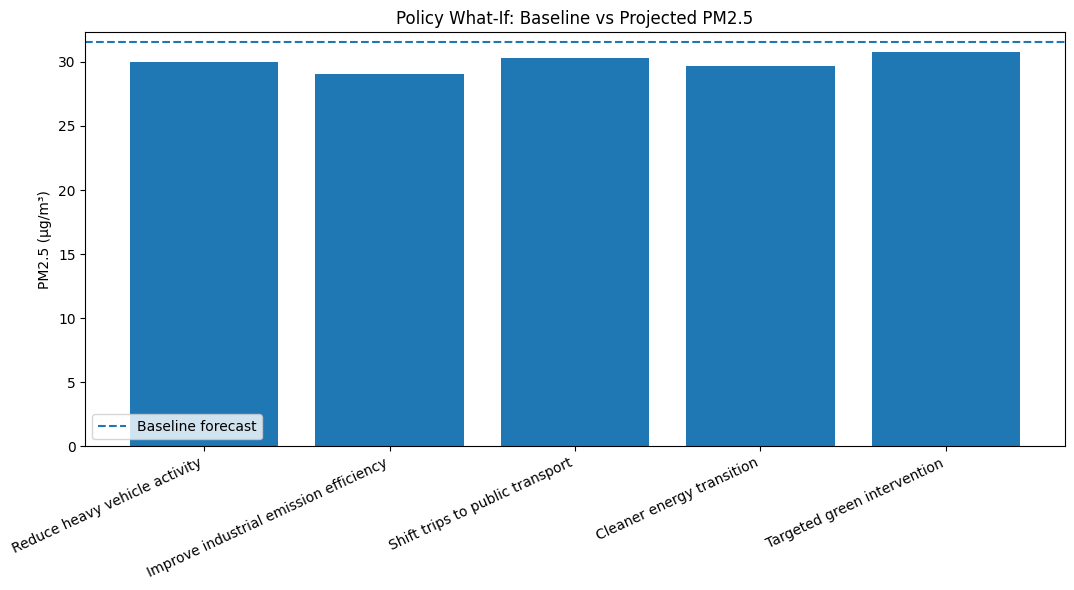

In [29]:
# 24. Policy What-If Simulator

baseline_pm25 = float(latest_prediction)

def simulate_policy(baseline, policy_row):
    reduction_pct = float(policy_row["assumed_pm25_reduction_pct"])
    projected = baseline * (1 - reduction_pct / 100)

    return {
        "policy_id": policy_row["policy_id"],
        "policy": policy_row["policy"],
        "baseline_pm25": round(baseline, 2),
        "projected_pm25": round(projected, 2),
        "estimated_reduction": round(baseline - projected, 2),
        "assumed_reduction_pct": reduction_pct,
        "budget_units": int(policy_row["budget_units"]),
        "estimate_type": "Scenario estimate"
    }

policy_results = pd.DataFrame(
    [simulate_policy(baseline_pm25, row) for _, row in policy_library.iterrows()]
)

display(policy_results.sort_values("projected_pm25"))

# Visual comparison
plt.figure(figsize=(11, 6))
plt.bar(policy_results["policy"], policy_results["projected_pm25"])
plt.axhline(baseline_pm25, linestyle="--", label="Baseline forecast")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Policy What-If: Baseline vs Projected PM2.5")
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 25. Budget-Aware Action Recommendation

For the prototype, `budget_units` are **relative planning units**, not rupee costs.

We rank policies using:

**Impact per budget unit = estimated PM2.5 reduction / budget units**

This gives the government user a transparent way to compare interventions when resources are limited.

In [30]:
# 25. Budget-Aware Action Recommendation

policy_results["impact_per_budget_unit"] = (
    policy_results["estimated_reduction"] / policy_results["budget_units"]
)

recommendations = policy_results.sort_values(
    ["impact_per_budget_unit", "estimated_reduction"],
    ascending=[False, False]
).reset_index(drop=True)

recommendations["recommendation_rank"] = np.arange(1, len(recommendations) + 1)

recommendations = recommendations[
    [
        "recommendation_rank",
        "policy_id",
        "policy",
        "projected_pm25",
        "estimated_reduction",
        "assumed_reduction_pct",
        "budget_units",
        "impact_per_budget_unit",
        "estimate_type"
    ]
]

display(recommendations)

print("\nTop prototype recommendation:")
display(recommendations.head(1))

,recommendation_rank,policy_id,policy,projected_pm25,estimated_reduction,assumed_reduction_pct,budget_units,impact_per_budget_unit,estimate_type
0,1,P05,Targeted green intervention,30.77,0.79,2.5,1,0.790000,Scenario estimate
1,2,P02,Improve industrial emission efficiency,29.04,2.53,8.0,4,0.632500,Scenario estimate
2,3,P03,Shift trips to public transport,30.30,1.26,4.0,2,0.630000,Scenario estimate
3,4,P01,Reduce heavy vehicle activity,29.99,1.58,5.0,3,0.526667,Scenario estimate
4,5,P04,Cleaner energy transition,29.67,1.89,6.0,5,0.378000,Scenario estimate



Top prototype recommendation:


,recommendation_rank,policy_id,policy,projected_pm25,estimated_reduction,assumed_reduction_pct,budget_units,impact_per_budget_unit,estimate_type
0,1,P05,Targeted green intervention,30.77,0.79,2.5,1,0.79,Scenario estimate


## 26. Multi-Policy Scenario

Government action may involve more than one intervention.  
This prototype lets us test a selected combination.

The combined result is still a **scenario estimate**. We use a simple capped additive reduction assumption to avoid producing an impossible reduction above 100%.

In [31]:
# 26. Multi-Policy Scenario

def simulate_policy_bundle(policy_ids, baseline):
    selected = policy_library[policy_library["policy_id"].isin(policy_ids)].copy()

    if selected.empty:
        raise ValueError("No valid policy IDs were selected.")

    total_assumed_reduction = selected["assumed_pm25_reduction_pct"].sum()
    total_assumed_reduction = min(total_assumed_reduction, 80.0)

    projected = baseline * (1 - total_assumed_reduction / 100)

    return {
        "selected_policies": ", ".join(selected["policy"].tolist()),
        "baseline_pm25": round(baseline, 2),
        "combined_assumed_reduction_pct": round(total_assumed_reduction, 2),
        "projected_pm25": round(projected, 2),
        "estimated_reduction": round(baseline - projected, 2),
        "total_budget_units": int(selected["budget_units"].sum()),
        "estimate_type": "Scenario estimate"
    }

# Example bundle for the prototype
selected_policy_ids = ["P01", "P03", "P05"]
bundle_result = simulate_policy_bundle(selected_policy_ids, baseline_pm25)
bundle_result

{'selected_policies': 'Reduce heavy vehicle activity, Shift trips to public transport, Targeted green intervention',
 'baseline_pm25': 31.56,
 'combined_assumed_reduction_pct': np.float64(11.5),
 'projected_pm25': np.float64(27.93),
 'estimated_reduction': np.float64(3.63),
 'total_budget_units': 6,
 'estimate_type': 'Scenario estimate'}

## 27. Policy Verification Framework ⭐

This is the final part of the closed-loop idea:

**Predict → Prioritize → Simulate → Act → Verify**

The verification function compares:
- baseline PM2.5 before intervention
- expected PM2.5 from the selected scenario
- observed PM2.5 after intervention

Because our current dataset has **no verified policy intervention date**, we do not fabricate an observed outcome. The function is ready for real post-intervention data.

In [32]:
# 27. Policy Verification Framework

def verify_policy_effect(
    baseline_observed_pm25,
    expected_reduction_pct,
    post_policy_observed_pm25
):
    baseline_observed_pm25 = float(baseline_observed_pm25)
    post_policy_observed_pm25 = float(post_policy_observed_pm25)
    expected_reduction_pct = float(expected_reduction_pct)

    expected_pm25 = baseline_observed_pm25 * (1 - expected_reduction_pct / 100)
    observed_reduction = baseline_observed_pm25 - post_policy_observed_pm25
    observed_reduction_pct = (
        observed_reduction / baseline_observed_pm25 * 100
        if baseline_observed_pm25 != 0 else np.nan
    )

    effectiveness_pct = (
        observed_reduction_pct / expected_reduction_pct * 100
        if expected_reduction_pct != 0 else np.nan
    )

    return {
        "baseline_observed_pm25": round(baseline_observed_pm25, 2),
        "expected_pm25": round(expected_pm25, 2),
        "post_policy_observed_pm25": round(post_policy_observed_pm25, 2),
        "expected_reduction_pct": round(expected_reduction_pct, 2),
        "observed_reduction_pct": round(observed_reduction_pct, 2),
        "policy_effectiveness_pct": round(effectiveness_pct, 2),
        "note": "Effectiveness is descriptive; causal attribution requires controlled/adjusted analysis."
    }

# Verification template — intentionally no fabricated post-policy observation.
verification_template = {
    "status": "Awaiting verified post-intervention observations",
    "required_inputs": [
        "baseline observed PM2.5",
        "policy implementation date/window",
        "post-policy observed PM2.5",
        "expected scenario reduction"
    ]
}
verification_template

{'status': 'Awaiting verified post-intervention observations',
 'required_inputs': ['baseline observed PM2.5',
  'policy implementation date/window',
  'post-policy observed PM2.5',
  'expected scenario reduction']}

## 28. Pollution Displacement Check ⭐

A policy may improve one area while pollution rises in a nearby area.

For a future multi-station dataset, this function compares pre/post changes across locations and flags a simple **possible displacement signal**.

This is a screening signal, not proof of causation.

In [33]:
# 28. Pollution Displacement Check

def displacement_check(location_changes, improved_threshold=-2.0, worsened_threshold=2.0):
    """
    location_changes: DataFrame with columns:
        location, change_pct
    Negative change = improvement.
    Positive change = worsening.
    """
    required = {"location", "change_pct"}
    missing = required - set(location_changes.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    improved = location_changes[location_changes["change_pct"] <= improved_threshold]
    worsened = location_changes[location_changes["change_pct"] >= worsened_threshold]

    possible_displacement = len(improved) > 0 and len(worsened) > 0

    return {
        "improved_locations": improved["location"].tolist(),
        "worsened_locations": worsened["location"].tolist(),
        "possible_displacement_signal": possible_displacement,
        "note": "Requires multi-location post-intervention observations for meaningful use."
    }

print("Displacement checker ready for future multi-station data.")

Displacement checker ready for future multi-station data.


## 29. Day 3 Outputs

Save the policy intelligence artifacts so the future FastAPI backend can use them.

In [34]:
# 29. Save Day 3 policy intelligence artifacts

policy_results_path = os.path.join(OUTPUT_DIR, "policy_scenario_results.csv")
recommendations_path = os.path.join(OUTPUT_DIR, "policy_recommendations.csv")
bundle_path = os.path.join(OUTPUT_DIR, "policy_bundle_result.json")
verification_path = os.path.join(OUTPUT_DIR, "policy_verification_template.json")

policy_results.to_csv(policy_results_path, index=False)
recommendations.to_csv(recommendations_path, index=False)

with open(bundle_path, "w", encoding="utf-8") as f:
    json.dump(bundle_result, f, indent=4)

with open(verification_path, "w", encoding="utf-8") as f:
    json.dump(verification_template, f, indent=4)

print("Day 3 saved:")
print("1.", policy_results_path)
print("2.", recommendations_path)
print("3.", bundle_path)
print("4.", verification_path)

Day 3 saved:
1. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_scenario_results.csv
2. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_recommendations.csv
3. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_bundle_result.json
4. C:\Users\Shiva Mishra\OneDrive\Desktop\Ecopredict\outputs\policy_verification_template.json


# ✅ Day 3 Complete

### Policy Intelligence now includes

- ✅ Policy Scenario Library
- ✅ What-If Simulator
- ✅ Baseline vs projected PM2.5
- ✅ Budget-aware recommendation
- ✅ Multi-policy bundle simulation
- ✅ Policy verification framework
- ✅ Pollution displacement screening
- ✅ Saved backend-ready outputs

### Eco Predict ML pipeline so far

**Day 1:** Data → Features → Train/Test Split → Model Training → Evaluation  
**Day 2:** Forecast → Anomaly Detection → Risk Score → Inspection Priority  
**Day 3:** Risk → Policy Simulation → Recommendation → Verification

### Next
**Day 4 — React Frontend**
